Epoch 1/20
10/10 [==============================] - 33s 3s/step - loss: 2.5738 - accuracy: 0.2200 - val_loss: 1.6925 - val_accuracy: 0.7368
Epoch 2/20
10/10 [==============================] - 29s 3s/step - loss: 1.5314 - accuracy: 0.4667 - val_loss: 1.6169 - val_accuracy: 0.7895
Epoch 3/20
10/10 [==============================] - 28s 3s/step - loss: 1.1401 - accuracy: 0.6267 - val_loss: 1.5461 - val_accuracy: 0.7895
Epoch 4/20
10/10 [==============================] - 27s 3s/step - loss: 0.6728 - accuracy: 0.7467 - val_loss: 1.4979 - val_accuracy: 0.8421
Epoch 5/20
10/10 [==============================] - 28s 3s/step - loss: 0.6729 - accuracy: 0.7467 - val_loss: 1.4474 - val_accuracy: 0.8947
Epoch 6/20
10/10 [==============================] - 28s 3s/step - loss: 0.4678 - accuracy: 0.8333 - val_loss: 1.3946 - val_accuracy: 0.9737
Epoch 7/20
10/10 [==============================] - 28s 3s/step - loss: 0.3712 - accuracy: 0.8667 - val_loss: 1.3389 - val_accuracy: 0.9737
Epoch 8/20
10/10 [==

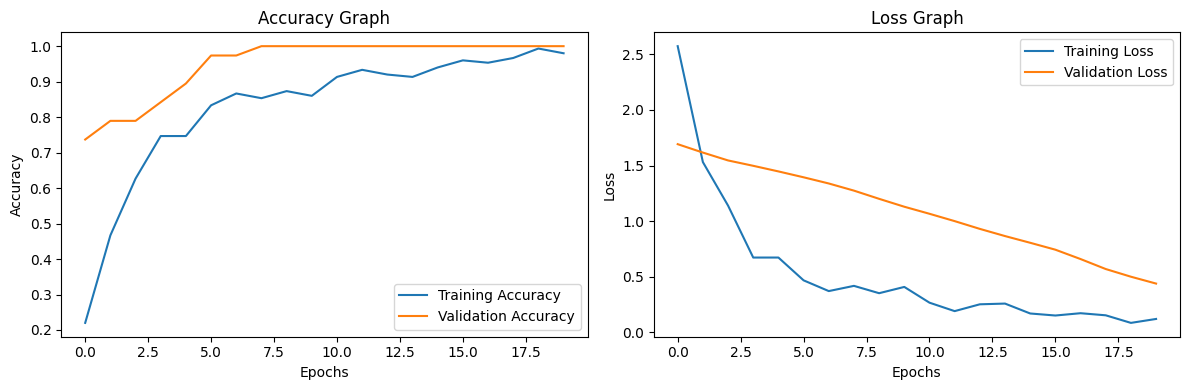

2/2 [==============================] - 7s 2s/step - loss: 0.4229 - accuracy: 1.0000
Test Accuracy: 100.00%
2/2 [==============================] - 7s 2s/step

Classification Report:
              precision    recall  f1-score   support

    sample 2       1.00      1.00      1.00         2
    sample 3       1.00      1.00      1.00        17
    sample 4       1.00      1.00      1.00        11
    sample 5       1.00      1.00      1.00         5
     sample6       1.00      1.00      1.00         5
     sample8       1.00      1.00      1.00         8

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



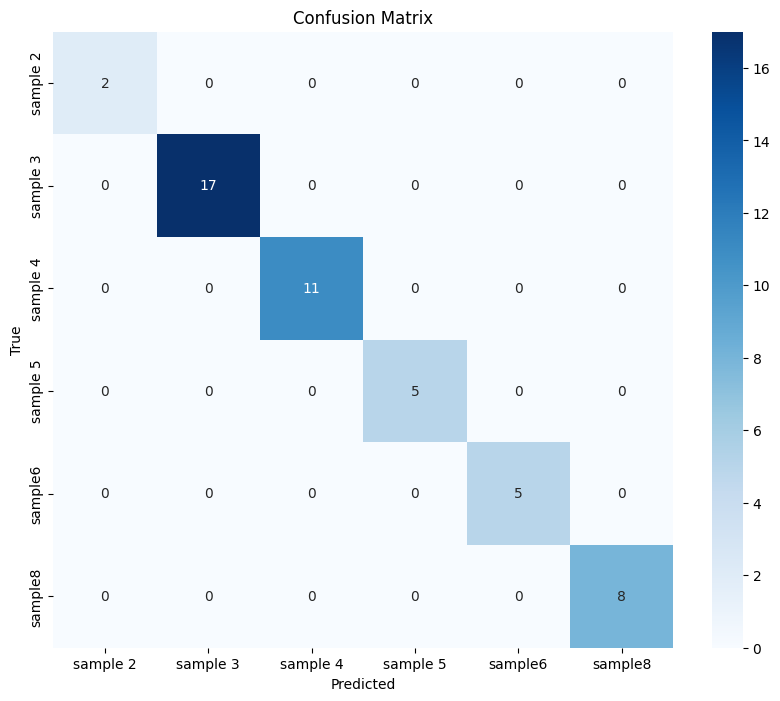

In [1]:
import os
import cv2
import numpy as np
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set image dimensions
IMG_SIZE = 224

# Function to load images and labels
def load_images_and_labels(dataset_path):
    images = []
    labels = []
    label_map = {}  # Map user folders to numeric labels
    label_index = 0

    for user_folder in os.listdir(dataset_path):
        user_path = os.path.join(dataset_path, user_folder)
        if os.path.isdir(user_path):
            # Assign numeric label
            if user_folder not in label_map:
                label_map[user_folder] = label_index
                label_index += 1

            for file in os.listdir(user_path):
                file_path = os.path.join(user_path, file)
                image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)  # Grayscale image
                image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))      # Resize to 224x224
                image = np.stack((image,)*3, axis=-1)               # Convert to 3 channels
                images.append(image)
                labels.append(label_map[user_folder])

    images = np.array(images) / 255.0  # Normalize
    labels = np.array(labels)
    return images, labels, label_map

# Load dataset
dataset_path = "fingerprint_dataset"
images, labels, label_map = load_images_and_labels(dataset_path)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)
y_train = to_categorical(y_train, num_classes=len(label_map))
y_test = to_categorical(y_test, num_classes=len(label_map))

# Hybrid VGG19 + Custom CNN model
def build_hybrid_model(num_classes):
    # Load VGG19 as feature extractor
    vgg_base = VGG19(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    for layer in vgg_base.layers:
        layer.trainable = False  # Freeze VGG19 layers

    # Add custom CNN layers after VGG19
    x = vgg_base.output
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Flatten the features and add fully connected layers
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    # Create the model
    model = Model(inputs=vgg_base.input, outputs=output)
    return model

# Build and compile the model
num_classes = len(label_map)
model = build_hybrid_model(num_classes)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks for training
checkpoint = ModelCheckpoint("hybrid_vgg19_cnn_model.h5", save_best_only=True, monitor='val_loss', mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=16,
    callbacks=[checkpoint, early_stopping]
)

# Plot accuracy and loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Confusion matrix and classification report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=label_map.keys()))

conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
